In [1]:
# main.py
import numpy as np
#import gym
#from DDPG_trial import DDPG
from collections import deque
from pathlib import Path
import pdb
import pandas as pd
import torch
from Utils.env_orig import env
from Utils.LSTM import LSTMModel  
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import random
import matplotlib.pyplot as plt
from tqdm import tqdm
np.random.seed(42)
import pdb 
M, N, J = 8, 20, 3
p_o = 1e-5
# Replay Buffer for Experience Replay
class ReplayBuffer:
    def __init__(self, max_size=int(1e6)):
        self.buffer = deque(maxlen=max_size)

    def add(self, state, next_state, action, reward):
        self.buffer.append((state, next_state, action, reward))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, next_state, action, reward = map(np.stack, zip(*batch))
        return (
            torch.FloatTensor(state),
            torch.FloatTensor(next_state),
            torch.FloatTensor(action),
            torch.FloatTensor(reward).unsqueeze(1),
            #torch.FloatTensor(done).unsqueeze(1),
        )

    def size(self):
        return len(self.buffer)

###########generate random discrete matrix for actions(should ideally come from the discretization procedure)


def generate_matrix(N, J):
    # Initialize an NxJ matrix filled with zeros
    matrix = np.zeros((N, J), dtype=int)
    
    # Ensure each column has at least one 1
    for j in range(J):
        # Randomly select a row to place the 1 in column j
        while True:
            row_index = np.random.randint(N)
            # Place the 1 only if that row currently contains no 1
            if np.sum(matrix[row_index]) == 0:
                matrix[row_index, j] = 1
                break
    
    # Fill remaining rows with either a single 1 or all 0s
    for i in range(N):
        if np.sum(matrix[i]) == 0:  # If the row is all zeros
            if np.random.rand() > 0.5:  # 50% chance to add a 1
                col_index = np.random.randint(J)
                matrix[i, col_index] = 1
    
    return matrix


In [2]:
#model = torch.load('LSTM.pth')
# Initialize the model architecture
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Model parameters
input_dim = N
hidden_dim = 128
output_dim = N
num_layers = 1

# Initialize the model, loss function and optimizer
model = LSTMModel(input_dim, hidden_dim, output_dim, num_layers).to(device)
#model = LSTMModel()  # Initialize your model with the required parameters

# Load the saved state dictionary
file_name = 'LSTM_state_dict.pth'
lstm_ckpt_path = Path("/home/sriniva3/Templates") / file_name
if lstm_ckpt_path.exists():
    try:
        model.load_state_dict(torch.load(lstm_ckpt_path))
        print(f"Loaded pretrained LSTM model from: {lstm_ckpt_path.resolve()}")
    except Exception as e:
        print(f"Found '{lstm_ckpt_path}', but could not load it.")
        print(f"Error: {e}")
        print("\nPlease run the LSTM_predict.py script first to save the model, and then run this pipeline again.")
        raise SystemExit(1)
else:
    print("\nPretrained LSTM model not found: 'LSTM_state_dict.pth'")
    print("Please run the LSTM_predict.py script first to save the model, and then run this pipeline again.")
    raise SystemExit(1)

Loaded pretrained LSTM model from: /home/sriniva3/Templates/LSTM_state_dict.pth


In [3]:
Ts = 10000
environ = env(Ts = Ts, N = N, M = M, J= J )
alltime_fast_fading_gains, ff_gains = environ.fast_fading_channel_coefficients()
TxRxds = environ.compute_TxRX()
alltime_PathGains = environ.large_scale_fading_channel_coefficients(TxRxds)


#### save ####
#np.save('alltime_fast_fading_gains.npy', alltime_fast_fading_gains)
#np.save('ff_gains.npy', ff_gains)
#np.save('TxRxds.npy', TxRxds)
#np.save('alltime_PathGains.npy',alltime_PathGains)


#### load ####
#'''
#alltime_fast_fading_gains = np.load('alltime_fast_fading_gains_50k.npy')
#ff_gains = np.load('ff_gains_50k.npy')
#TxRxds = np.load('TxRxds_50k.npy')
#alltime_PathGains = np.load('alltime_PathGains_50k.npy')
#'''

100%|██████████| 9999/9999 [00:01<00:00, 5712.20it/s]


In [5]:
TimeVaris = np.arange(0,5,5/Ts)
len(TimeVaris)

10000

In [7]:
def get_lstm_pred_SINR(ts_start, ts_end, b=None, interfers_actions=None, flag=None, b_actions=None):
    history = 10
    SINR_nxt_lstm = np.zeros((J, N), dtype=np.float32)

    model.eval()
    with torch.no_grad():
        for j in range(J):
            inp = []
            for ts in np.arange(ts_start, ts_end):
                SINR = environ.get_next_state(
                    alltime_PathGains,
                    alltime_fast_fading_gains,
                    ts=ts,
                    b=b,
                    interfers_actions=interfers_actions,
                    flag=flag,
                    b_actions=b_actions
                )[0]
                inp.append(SINR[:, j])

            inp = np.array(inp, dtype=np.float32).reshape(1, history, N)
            pred = model(torch.tensor(inp, dtype=torch.float32, device=device))
            SINR_nxt_lstm[j, :] = pred.cpu().numpy()[0]

    SINR_nxt_lstm = np.transpose(SINR_nxt_lstm)
    return SINR_nxt_lstm

In [9]:
# Actor Network
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, max_action):
        super(Actor, self).__init__()
        self.fc1 = nn.Linear(state_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128,64)
        self.fc4 = nn.Linear(64, action_dim)
        self.max_action = max_action

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = torch.sigmoid(self.fc4(x))
        return x * self.max_action

# Critic Network
class Critic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(Critic, self).__init__()
        self.fc1 = nn.Linear(state_dim + action_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)

    def forward(self, state, action):
        x = torch.cat([state, action], 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        q_value = F.relu(self.fc3(x))
        #pdb.set_trace()
        return q_value

In [10]:
# DDPG Agent
class DDPG:
    def __init__(self, state_dim, action_dim, max_action):
        self.actor = Actor(state_dim, action_dim, max_action).to(torch.device("cpu"))
        self.actor_target = Actor(state_dim, action_dim, max_action).to(torch.device("cpu"))
        self.actor_target.load_state_dict(self.actor.state_dict())
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=0.5e-3)

        self.critic = Critic(state_dim, action_dim).to(torch.device("cpu"))
        self.critic_target = Critic(state_dim, action_dim).to(torch.device("cpu"))
        self.critic_target.load_state_dict(self.critic.state_dict())
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=0.5e-3)

        self.max_action = max_action
        self.discount = 0.99
        self.tau = 0.005

    def select_action(self, state):
        state = torch.FloatTensor(state.reshape(1, -1)).to(torch.device("cpu"))
        action = self.actor(state).cpu().data.numpy().flatten()
        return action

    def train(self, replay_buffer, t, batch_size=64):
        # Sample a batch of transitions from the replay buffer
        state, next_state, action, reward = replay_buffer.sample(batch_size)
        next_state = next_state.view(batch_size,-1)
        state = state.view(batch_size,-1)
        action = action.view(batch_size,-1)
        # Compute the target Q value
        #pdb.set_trace()
        next_action = self.actor_target(next_state)
        target_q = self.critic_target(next_state, next_action)
        #target_q1, target_q2 = self.critic_target(next_state, next_action)
        #target_q = torch.min(target_q1, target_q2)
        if t < 256:
            not_done = 1.0
        else:
            not_done = 0.0
        #pdb.set_trace()
        target_q = reward + not_done * self.discount * target_q.detach()

        # Get current Q estimate
        current_q = self.critic(state, action)
        #current_q1, current_q2 = self.critic(state, action)
        #current_q = torch.min(current_q1, current_q2)
        # Compute critic loss
        critic_loss = F.mse_loss(current_q, target_q)

        # Optimize the critic
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        # Compute actor loss
        actor_loss = -self.critic(state, self.actor(state)).mean()

        # Optimize the actor
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        # Update the target networks
        for param, target_param in zip(self.critic.parameters(), self.critic_target.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

        for param, target_param in zip(self.actor.parameters(), self.actor_target.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

In [11]:
######### get binary discretized action #########

def return_bin_descrete_action(N,J,uhat):
    u = np.zeros((N,J))
    
    def select_unique_max_indices(matrix):
        
        selected_rows = set()  # To track used row indices
        result_indices = []
    
        # Iterate through each column
        for j in range(J):
            # Sort the row indices by the column values in descending order
            sorted_row_indices = np.argsort(matrix[:, j])[::-1]
            
            # Find the first available row index that has not been selected
            for row in sorted_row_indices:
                if row not in selected_rows:
                    selected_rows.add(row)
                    result_indices.append((row, j))
                    break
        
        return result_indices

    max_indices = select_unique_max_indices(uhat)
    
    # Display the result
    #print(uhat)
    #print("Selected (row, column) indices:", max_indices)
    
    allocated_resos = []
    for ind in max_indices:
        u[ind[0],ind[1]] = 1.0
        allocated_resos.extend([ind[0]])
    unallocated_resos = np.array([r for r in range(N) if r not in allocated_resos])
    
    
    v = np.concatenate((np.zeros((1,J)), np.eye(J)))
    
    
    for r in unallocated_resos:
        ind = np.argmin([np.linalg.norm(uhat[r,:] - v[n,:]) for n in range(v.shape[0])])
        u[r,:] = v[ind,:]
    return u

In [12]:
T = 256

state_dim = 2 * N * J
action_dim = N * J
max_action = 1.0
time_slots = np.arange(0, Ts)

NUM_AGENTS = M

agents = [DDPG(state_dim, action_dim, max_action) for _ in range(NUM_AGENTS)]
replay_buffers = [ReplayBuffer() for _ in range(NUM_AGENTS)]

episodes = 100
batch_size = 128
ts_counter = 0


def build_interferers_actions_for_agent(agent_idx, joint_actions):
    """
    joint_actions: list of length M, each entry shape (N, J)
    returns shape (M-1, J, N), matching env.py expectation
    """
    return np.stack(
        [joint_actions[k].T for k in range(NUM_AGENTS) if k != agent_idx],
        axis=0
    )

In [ ]:
epi_rewards = [[] for _ in range(NUM_AGENTS)]
P_e_all = [[] for _ in range(NUM_AGENTS)]

prev_actions = [generate_matrix(N, J) for _ in range(NUM_AGENTS)]

for episode in tqdm(range(episodes)):
    # -------- initial states for all agents --------
    states = []
    for k in range(NUM_AGENTS):
        interferers_prev = build_interferers_actions_for_agent(k, prev_actions)

        state_lstm_k = get_lstm_pred_SINR(
            ts_start=ts_counter,
            ts_end=ts_counter + 10,
            b=k,
            interfers_actions=interferers_prev,
            b_actions=prev_actions[k]
        )

        state_k = np.stack((state_lstm_k, prev_actions[k]), axis=0)
        states.append(state_k)

    episode_rewards = np.zeros(NUM_AGENTS, dtype=np.float32)

    # -------- roll out one episode --------
    for t in range(T):
        # 1) each agent selects an action from its current state
        joint_actions = []
        for k in range(NUM_AGENTS):
            action_cont = agents[k].select_action(np.array(states[k]))
            action_disc = return_bin_descrete_action(N, J, np.reshape(action_cont, (N, J)))
            joint_actions.append(action_disc)

        # 2) compute next states and rewards for all agents
        next_states = []
        step_rewards = np.zeros(NUM_AGENTS, dtype=np.float32)

        for k in range(NUM_AGENTS):
            interferers_k = build_interferers_actions_for_agent(k, joint_actions)

            next_state_lstm_k = get_lstm_pred_SINR(
                ts_start=ts_counter + 1,
                ts_end=ts_counter + 11,
                b=k,
                interfers_actions=interferers_k,
                b_actions=joint_actions[k]
            )

            next_state_k = np.stack((next_state_lstm_k, joint_actions[k]), axis=0)

            _, p_e_k, reward_k = environ.compute_rewards(
                alltime_PathGains,
                alltime_fast_fading_gains,
                ts=time_slots[ts_counter + 10],
                b=k,
                interfers_actions=interferers_k,
                b_actions=joint_actions[k]
            )

            P_e_all[k].append(p_e_k)

            reward_k = np.sum(reward_k)
            step_rewards[k] = reward_k
            episode_rewards[k] += reward_k

            replay_buffers[k].add(
                states[k],
                next_state_k,
                joint_actions[k],
                reward_k
            )

            next_states.append(next_state_k)

        # 3) train each agent
        for k in range(NUM_AGENTS):
            if replay_buffers[k].size() > batch_size:
                agents[k].train(replay_buffers[k], t, batch_size)

        # 4) move to next step
        states = next_states
        prev_actions = [a.copy() for a in joint_actions]

        ts_counter += 1
        if ts_counter >= Ts - 10:
            ts_counter = 0

    # store episode-average rewards
    for k in range(NUM_AGENTS):
        epi_rewards[k].append(episode_rewards[k] / T)

/tmp/ipykernel_2950285/84676287.py:15: RuntimeWarning: All-NaN slice encountered
  err_max = np.nanmax(err_prob_matrix, axis=1)


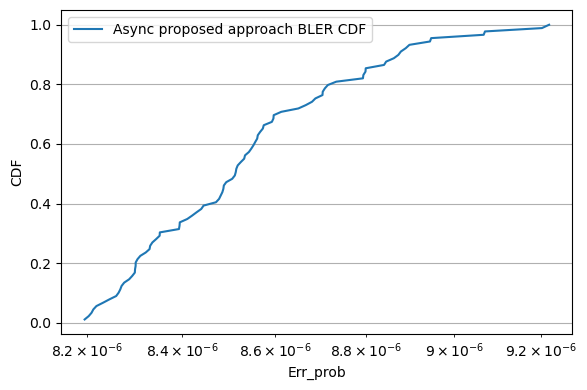

In [28]:
reward_df = pd.DataFrame({
    f"agent {k+1}": np.array(epi_rewards[k]) / (N * J)
    for k in range(NUM_AGENTS)
})

reward_smooth = reward_df.rolling(window=2).mean()


err_prob_df = p_o * (10 ** (-reward_smooth))
def return_cdf(a):
    sorted_a = np.sort(a)
    cdf = np.arange(1, len(sorted_a) + 1) / len(sorted_a)
    return sorted_a, cdf
err_prob_matrix = err_prob_df.to_numpy()
err_max = np.nanmax(err_prob_matrix, axis=1)
err_max = np.asarray(err_max).reshape(-1)
err_max = err_max[np.isfinite(err_max) & (err_max > 0)]
cutoff = np.percentile(err_max, 10)
err_max_main = err_max[err_max >= cutoff]
a, cdf = return_cdf(err_max_main)
plt.figure(figsize=[6, 4])
plt.semilogx(a, cdf, label='Async proposed approach BLER CDF')
plt.grid()
plt.xlabel('Err_prob')
plt.ylabel('CDF')
plt.legend()
plt.tight_layout()
plt.show()